In [16]:
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/TA_KIM/gsea_data')
dir = os.getcwd()


Mounted at /content/drive


In [17]:
g1_neg_tsv = f'{dir}/g1_na_neg.tsv'
g1_pos_tsv = f'{dir}/g1_na_pos.tsv'

g2_neg_tsv = f'{dir}/g2_na_neg.tsv'
g2_pos_tsv = f'{dir}/g2_na_pos.tsv'

g3_neg_tsv = f'{dir}/g3_na_neg.tsv'
g3_pos_tsv = f'{dir}/g3_na_pos.tsv'

In [20]:
g1_neg = pd.read_csv(g1_neg_tsv, delimiter='\t')
g1_pos = pd.read_csv(g1_pos_tsv, delimiter='\t')

g2_neg = pd.read_csv(g2_neg_tsv, delimiter='\t')
g2_pos = pd.read_csv(g2_pos_tsv, delimiter='\t')

g3_neg = pd.read_csv(g3_neg_tsv, delimiter='\t')
g3_pos = pd.read_csv(g3_pos_tsv, delimiter='\t')

In [107]:
import pandas as pd

def filter_pval(gsea_df, pval, filename):
    # Filter rows where 'NOM p-val' < pval
    gsea_pos = gsea_df[gsea_df['NOM p-val'] < pval]
    gsea_pos.to_csv(filename, sep='\t', index=False)
    return gsea_pos

def process_gsea(gsea_pos, gsea_neg, pval):
    # Combine positive and negative GSEA results
    gsea_pos_neg = pd.concat([gsea_neg, gsea_pos])

    # Filter rows where 'NOM p-val' > pval
    gsea_pos_neg = gsea_pos_neg[gsea_pos_neg['NOM p-val'] < pval]

    # Order by NES in descending order
    gsea_pos_neg = gsea_pos_neg.sort_values(by='NES', ascending=False)

    # Split the 'NAME' column based on '%' and take the first part
    gsea_pos_neg['NAME'] = gsea_pos_neg['NAME'].str.split('%').str[0]

    return gsea_pos_neg


In [108]:
gsea_g1_pos_01 = filter_pval(g1_pos, 0.01, 'g1_pos_01.tsv')
gsea_g1_neg_01 = filter_pval(g1_neg, 0.01, 'g1_neg_01.tsv')
gsea_g2_pos_01 = filter_pval(g2_pos, 0.01, 'g2_pos_01.tsv')
gsea_g2_neg_01 = filter_pval(g2_neg, 0.01, 'g2_neg_01.tsv')
gsea_g3_pos_01 = filter_pval(g3_pos, 0.01, 'g3_pos_01.tsv')
gsea_g3_neg_01 = filter_pval(g3_neg, 0.01, 'g3_neg_01.tsv')


In [69]:
g1_neg_pos = process_gsea(g1_pos, g1_neg, 0.01)
g1_neg_pos

,NAME,GS<br> follow link to MSigDB,GS DETAILS,SIZE,ES,NES,NOM p-val,FDR q-val,FWER p-val,RANK AT MAX,LEADING EDGE,Unnamed: 11
0,REGULATION OF KINASE ACTIVITY,REGULATION OF KINASE ACTIVITY%GOBP%GO:0043549,Details ...,12,0.638026,1.807109,0.0000,0.082177,0.0295,0,"tags=8%, list=0%, signal=8%",NaN
1,REGULATION OF TRANSFERASE ACTIVITY,REGULATION OF TRANSFERASE ACTIVITY%GOBP%GO:005...,Details ...,14,0.588619,1.785982,0.0000,0.042184,0.0300,0,"tags=7%, list=0%, signal=7%",NaN
2,REGULATION OF PROTEIN KINASE ACTIVITY,REGULATION OF PROTEIN KINASE ACTIVITY%GOBP%GO:...,Details ...,11,0.662880,1.748023,0.0000,0.037969,0.0395,0,"tags=9%, list=0%, signal=9%",NaN
6,REGULATION OF PHOSPHATE METABOLIC PROCESS,REGULATION OF PHOSPHATE METABOLIC PROCESS%GOBP...,Details ...,19,0.392968,1.330197,0.0000,0.135645,0.2730,10,"tags=11%, list=3%, signal=10%",NaN
6,IMMUNE SYSTEM,IMMUNE SYSTEM%REACTOME%R-HSA-168256.9,Details ...,33,-0.689341,-1.261017,0.0095,1.000000,1.0000,96,"tags=45%, list=24%, signal=55%",NaN


In [70]:
g2_neg_pos = process_gsea(g2_pos, g2_neg, 0.01)
g2_neg_pos

,NAME,GS<br> follow link to MSigDB,GS DETAILS,SIZE,ES,NES,NOM p-val,FDR q-val,FWER p-val,RANK AT MAX,LEADING EDGE,Unnamed: 11
0,REPRODUCTIVE PROCESS,REPRODUCTIVE PROCESS%GOBP%GO:0022414,Details ...,17,0.621094,2.068726,0.001508,0.063825,0.0865,54,"tags=47%, list=14%, signal=52%",NaN
1,SEXUAL REPRODUCTION,SEXUAL REPRODUCTION%GOBP%GO:0019953,Details ...,14,0.591137,1.884515,0.002990,0.140930,0.3340,54,"tags=50%, list=14%, signal=56%",NaN
2,DEVELOPMENTAL PROCESS INVOLVED IN REPRODUCTION,DEVELOPMENTAL PROCESS INVOLVED IN REPRODUCTION...,Details ...,11,0.622344,1.880800,0.006051,0.096257,0.3400,54,"tags=45%, list=14%, signal=51%",NaN
3,SKELETAL SYSTEM DEVELOPMENT,SKELETAL SYSTEM DEVELOPMENT%GOBP%GO:0001501,Details ...,12,0.609267,1.859753,0.003030,0.084990,0.3835,57,"tags=58%, list=14%, signal=66%",NaN
4,EMBRYONIC MORPHOGENESIS,EMBRYONIC MORPHOGENESIS%GOBP%GO:0048598,Details ...,11,0.620596,1.840280,0.005848,0.078210,0.4265,74,"tags=73%, list=19%, signal=87%",NaN
6,SYSTEM DEVELOPMENT,SYSTEM DEVELOPMENT%GOBP%GO:0048731,Details ...,51,0.394803,1.742577,0.001938,0.113876,0.6805,64,"tags=39%, list=16%, signal=41%",NaN
7,MULTICELLULAR ORGANISM DEVELOPMENT,MULTICELLULAR ORGANISM DEVELOPMENT%GOBP%GO:000...,Details ...,57,0.366078,1.684871,0.006110,0.143556,0.7950,64,"tags=37%, list=16%, signal=38%",NaN
10,CELL DIFFERENTIATION,CELL DIFFERENTIATION%GOBP%GO:0030154,Details ...,57,0.363495,1.643886,0.003766,0.134762,0.8725,66,"tags=39%, list=17%, signal=40%",NaN
11,CELLULAR DEVELOPMENTAL PROCESS,CELLULAR DEVELOPMENTAL PROCESS%GOBP%GO:0048869,Details ...,57,0.363495,1.634886,0.000000,0.131241,0.8870,66,"tags=39%, list=17%, signal=40%",NaN
12,DEVELOPMENTAL PROCESS,DEVELOPMENTAL PROCESS%GOBP%GO:0032502,Details ...,82,0.325529,1.593115,0.000000,0.156624,0.9390,58,"tags=29%, list=15%, signal=27%",NaN


In [71]:
g3_neg_pos = process_gsea(g3_pos, g3_neg, 0.01)
g3_neg_pos

,NAME,GS<br> follow link to MSigDB,GS DETAILS,SIZE,ES,NES,NOM p-val,FDR q-val,FWER p-val,RANK AT MAX,LEADING EDGE,Unnamed: 11
0,EMBRYO DEVELOPMENT,EMBRYO DEVELOPMENT%GOBP%GO:0009790,Details ...,15,0.727109,2.073979,0.001300,0.048888,0.0480,63,"tags=67%, list=16%, signal=76%",NaN
1,EMBRYONIC MORPHOGENESIS,EMBRYONIC MORPHOGENESIS%GOBP%GO:0048598,Details ...,11,0.784887,2.060589,0.001259,0.028673,0.0565,63,"tags=73%, list=16%, signal=84%",NaN
2,TISSUE DEVELOPMENT,TISSUE DEVELOPMENT%GOBP%GO:0009888,Details ...,25,0.609372,1.990222,0.000000,0.041088,0.1160,83,"tags=56%, list=21%, signal=66%",NaN
3,EPITHELIUM DEVELOPMENT,EPITHELIUM DEVELOPMENT%GOBP%GO:0060429,Details ...,17,0.659114,1.940281,0.000000,0.048982,0.1770,47,"tags=47%, list=12%, signal=51%",NaN
4,ANIMAL ORGAN MORPHOGENESIS,ANIMAL ORGAN MORPHOGENESIS%GOBP%GO:0009887,Details ...,17,0.659243,1.939199,0.001330,0.040019,0.1805,76,"tags=59%, list=19%, signal=70%",NaN
5,REPRODUCTIVE PROCESS,REPRODUCTIVE PROCESS%GOBP%GO:0022414,Details ...,17,0.648741,1.922936,0.005044,0.039415,0.2100,81,"tags=65%, list=20%, signal=78%",NaN
6,TUBE DEVELOPMENT,TUBE DEVELOPMENT%GOBP%GO:0035295,Details ...,10,0.750510,1.881987,0.006075,0.049078,0.2900,31,"tags=50%, list=8%, signal=53%",NaN
7,NERVOUS SYSTEM PROCESS,NERVOUS SYSTEM PROCESS%GOBP%GO:0050877,Details ...,13,0.678970,1.879601,0.002581,0.043595,0.2930,49,"tags=54%, list=12%, signal=59%",NaN
8,ANATOMICAL STRUCTURE MORPHOGENESIS,ANATOMICAL STRUCTURE MORPHOGENESIS%GOBP%GO:000...,Details ...,32,0.539228,1.873735,0.001372,0.040638,0.3040,76,"tags=47%, list=19%, signal=53%",NaN
9,ANIMAL ORGAN DEVELOPMENT,ANIMAL ORGAN DEVELOPMENT%GOBP%GO:0048513,Details ...,41,0.509925,1.853495,0.001397,0.043444,0.3510,76,"tags=44%, list=19%, signal=49%",NaN


In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

def plot_gsea(gsea_pos_neg, title, y_spacing=1, x_size = 10,  y_size = 10):
    # Sort the data by NES values for better visualization
    gsea_pos_neg = gsea_pos_neg.sort_values('NES')

    # Normalize the SIZE column for dot sizes
    size_min, size_max = 250, 750  # Adjust these values as needed
    gsea_pos_neg['size_normalized'] = ((gsea_pos_neg['SIZE'] - gsea_pos_neg['SIZE'].min()) /
                                       (gsea_pos_neg['SIZE'].max() - gsea_pos_neg['SIZE'].min()) *
                                       (size_max - size_min) + size_min)

    # Create the plot
    plt.figure(figsize=(x_size, y_size))

    # Set distance between y data points
    y_positions = range(0, y_spacing * len(gsea_pos_neg), y_spacing)

    # Scatter plot for negative NES
    plt.scatter(gsea_pos_neg[gsea_pos_neg['NES'] < 0]['NES'],
                y_positions[:len(gsea_pos_neg[gsea_pos_neg['NES'] < 0])],
                s=gsea_pos_neg[gsea_pos_neg['NES'] < 0]['size_normalized'],
                color='blue', label='Negative NES')

    # Scatter plot for positive NES
    plt.scatter(gsea_pos_neg[gsea_pos_neg['NES'] > 0]['NES'],
                y_positions[-len(gsea_pos_neg[gsea_pos_neg['NES'] > 0]):],
                s=gsea_pos_neg[gsea_pos_neg['NES'] > 0]['size_normalized'],
                color='red', label='Positive NES')

    # Add text annotations for gene count
    for i, (index, row) in enumerate(gsea_pos_neg.iterrows()):
        plt.text(row['NES'], y_positions[i], str(row['SIZE']),
                 ha='center', va='center', fontsize=12, color='black')

    # Custom legend handles with specific sizes
    handle_neg = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', markersize=10, label='Hypomethylated')
    handle_pos = mlines.Line2D([], [], color='red', marker='o', linestyle='None', markersize=10, label='Hypermethylated')

    # Add custom legend
    plt.legend(handles=[handle_neg, handle_pos])

    # Add labels and title
    plt.xlabel('Normalized Enrichment Score (NES)')
    plt.ylabel('Gene Set')
    plt.title(f'GO Enrichment Plot: {title}')

    # Set x-axis range
    plt.xlim(-2.5, 2.5)

    # Add grid lines and bold vertical line at x = 0
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=2)  # Bold vertical line at NES=0

    # Adjust y-axis ticks and labels
    plt.yticks(ticks=y_positions, labels=gsea_pos_neg['NAME'], fontsize = 12)

    # Show the plot
    plt.tight_layout()
    plt.show()
'''
# Example usage:
data = {
    'NAME': ['GeneSet1', 'GeneSet2', 'GeneSet3', 'GeneSet4', 'GeneSet5'],
    'NES': [-2.3, 1.8, -1.5, 2.1, -2.0],
    'NOM p-val': [0.01, 0.02, 0.03, 0.04, 0.05],
    'SIZE': [10, 20, 15, 25, 10]
}

# Create a DataFrame
gsea_pos_neg = pd.DataFrame(data)

# Plot the GSEA results
plot_gsea(gsea_pos_neg, 'plot', y_spacing=1)
'''


"\n# Example usage:\ndata = {\n    'NAME': ['GeneSet1', 'GeneSet2', 'GeneSet3', 'GeneSet4', 'GeneSet5'],\n    'NES': [-2.3, 1.8, -1.5, 2.1, -2.0],\n    'NOM p-val': [0.01, 0.02, 0.03, 0.04, 0.05],\n    'SIZE': [10, 20, 15, 25, 10]\n}\n\n# Create a DataFrame\ngsea_pos_neg = pd.DataFrame(data)\n\n# Plot the GSEA results\nplot_gsea(gsea_pos_neg, 'plot', y_spacing=1)\n"

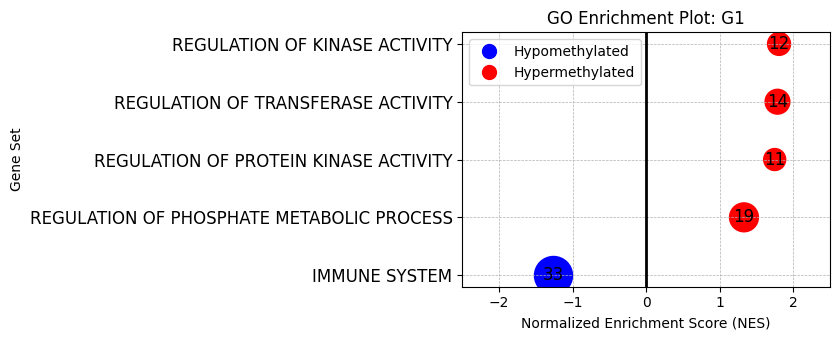

In [103]:
plot_gsea(g1_neg_pos, 'G1',x_size = 8.5,y_size = 3.5)

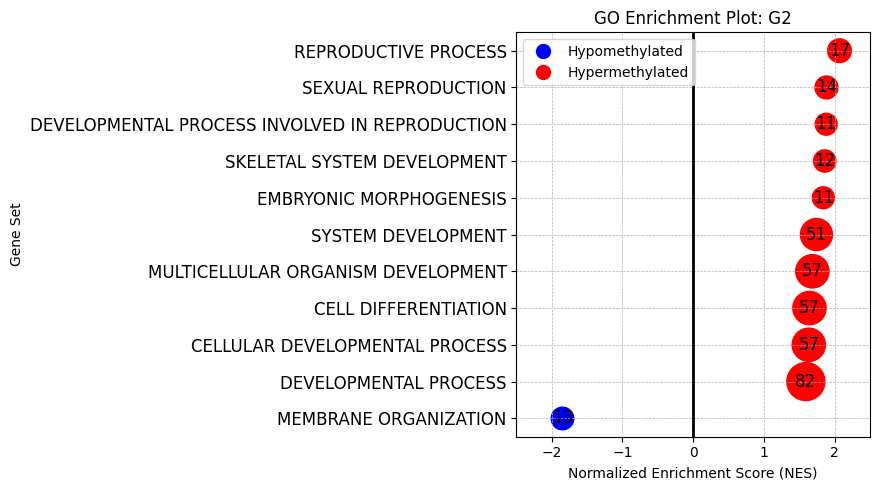

In [94]:
plot_gsea(g2_neg_pos, 'G2',x_size = 8.9,y_size = 5)

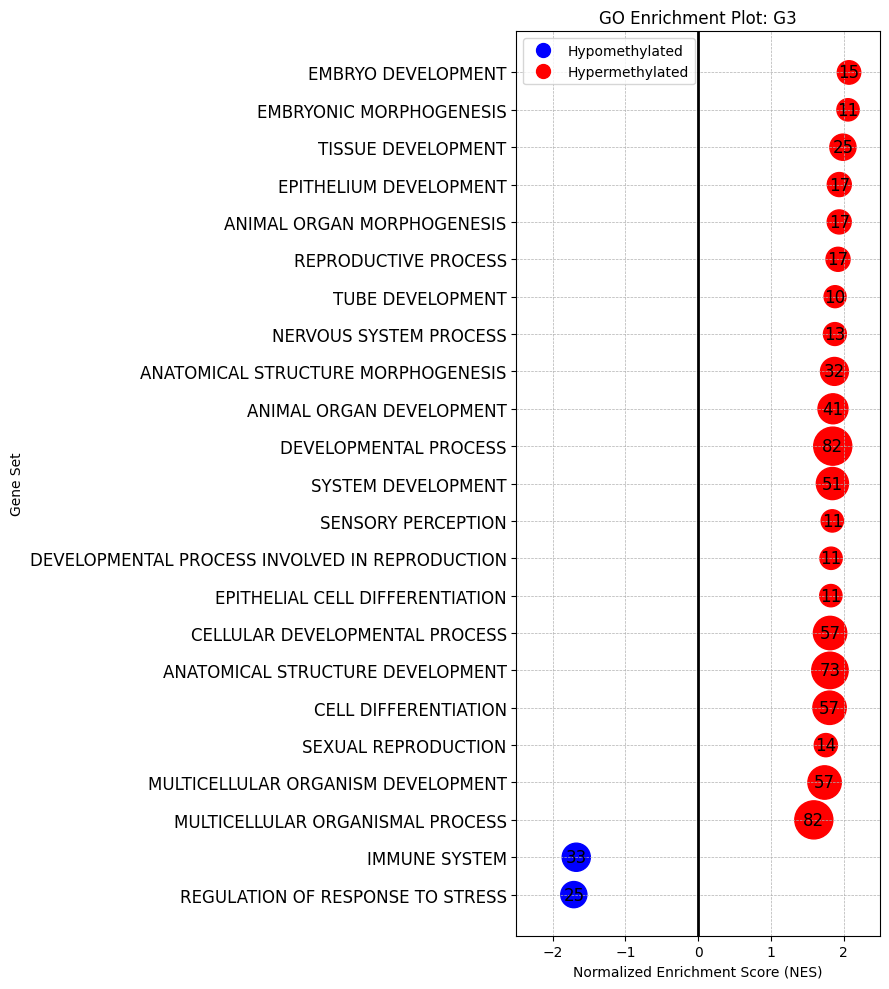

In [92]:
plot_gsea(g3_neg_pos, 'G3',x_size = 9,y_size = 10)